In [14]:
# ===============================
# STEP 0 — IMPORT LIBRARIES
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [15]:
# ===============================
# STEP 1 — LOAD DATA
# ===============================

df = pd.read_csv("Global_Pollution_Analysis.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [16]:
# ===============================
# STEP 2 — CLEAN MISSING VALUES
# ===============================

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Fill numeric with mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
# ===============================
# STEP 3 — ENCODE CATEGORICAL DATA
# ===============================

df = pd.get_dummies(df, columns=['Country'], drop_first=True)

In [18]:
# ===============================
# STEP 4 — DEFINE X AND y
# ===============================

target = "Energy_Recovered (in GWh)"

X = df.drop(columns=[target])
y = df[target]

In [19]:
# ===============================
# STEP 5 — SPLIT DATA
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
# ===============================
# STEP 6 — SCALE FEATURES
# ===============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# ===============================
# STEP 7 — LINEAR REGRESSION
# ===============================

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("📊 Linear Regression")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

📊 Linear Regression
R2 Score: -1.5226378682196158
RMSE: 246.9879060113595
MAE: 189.92439487046124


In [22]:
# ===============================
# STEP 8 — NEURAL NETWORK TUNING
# ===============================

param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'learning_rate_init': [0.001, 0.0005],
    'alpha': [0.0001, 0.001]
}

search = RandomizedSearchCV(
    MLPRegressor(max_iter=2000, random_state=42),
    param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_scaled, y_train)

best_nn = search.best_estimator_

y_pred_nn = best_nn.predict(X_test_scaled)

print("\n🧠 Neural Network (Tuned)")
print("Best Params:", search.best_params_)
print("R2 Score:", r2_score(y_test, y_pred_nn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn)))
print("MAE:", mean_absolute_error(y_test, y_pred_nn))


🧠 Neural Network (Tuned)
Best Params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.0001}
R2 Score: -0.36988372437411954
RMSE: 182.00783581908422
MAE: 145.36445587499867


In [23]:
# ===============================
# STEP 9 — MODEL COMPARISON
# ===============================

results = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_nn)
    ]
})

print("\n📈 Model Comparison")
print(results)


📈 Model Comparison
               Model  R2 Score
0  Linear Regression -1.522638
1     Neural Network -0.369884


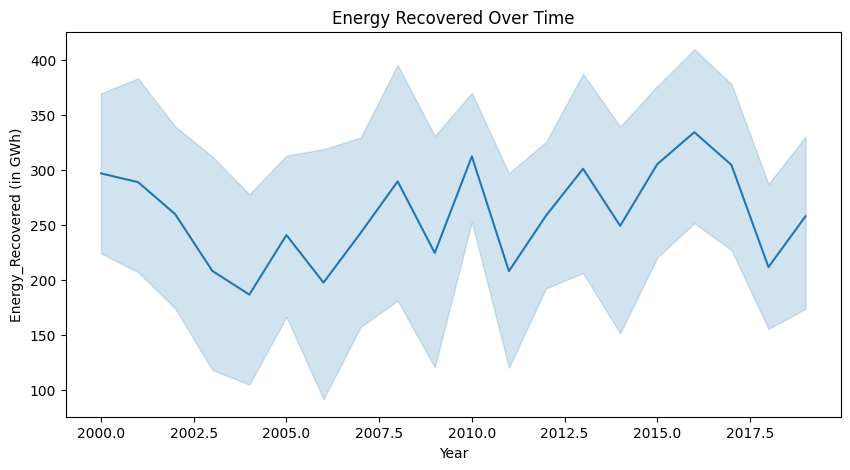

In [24]:
# ===============================
# STEP 10 — TEMPORAL TREND
# ===============================

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Year",
    y="Energy_Recovered (in GWh)"
)

plt.title("Energy Recovered Over Time")
plt.show()

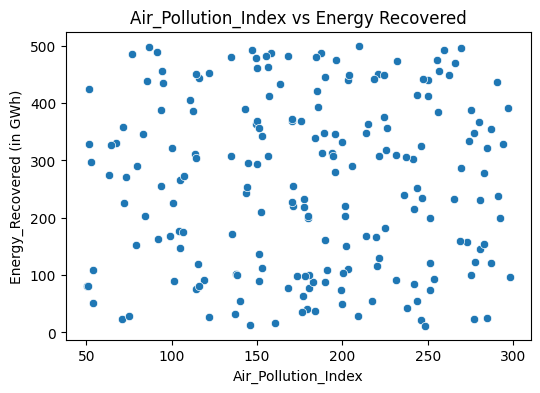

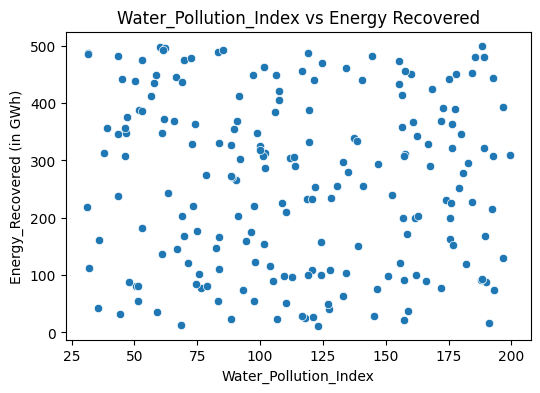

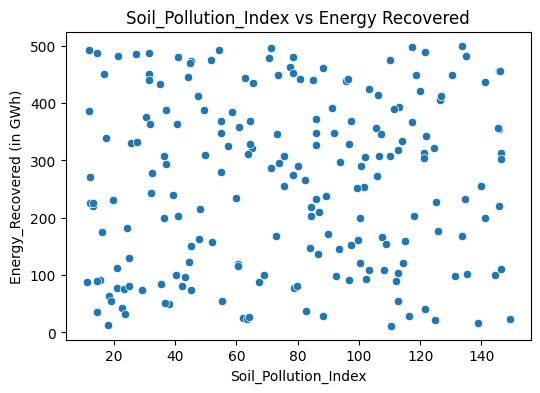

In [25]:
# ===============================
# STEP 11 — POLLUTION vs ENERGY
# ===============================

pollution_cols = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index"
]

for col in pollution_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df["Energy_Recovered (in GWh)"])
    plt.title(f"{col} vs Energy Recovered")
    plt.show()

In [26]:
# ===============================
# STEP 12 — CLUSTERING
# ===============================

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(
    scaler.fit_transform(df.select_dtypes(include=np.number))
)

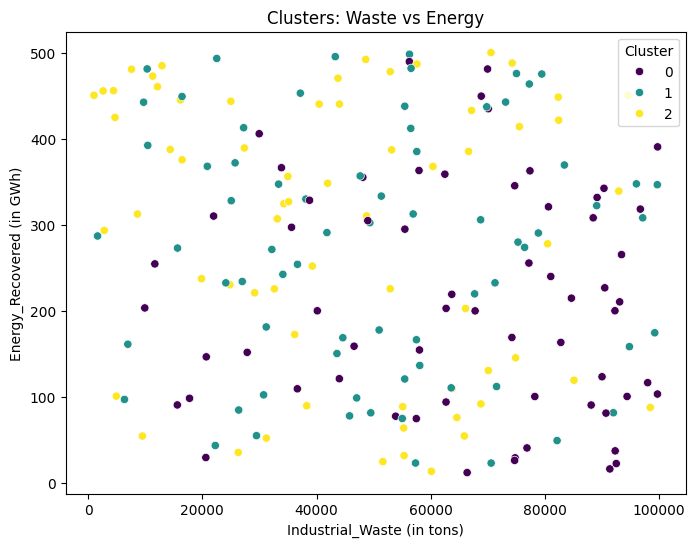

In [27]:
# ===============================
# STEP 13 — CLUSTER PLOT
# ===============================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Industrial_Waste (in tons)"],
    y=df["Energy_Recovered (in GWh)"],
    hue=df["Cluster"],
    palette="viridis"
)

plt.title("Clusters: Waste vs Energy")
plt.show()

In [28]:
# ===============================
# STEP 14 — CLUSTER SUMMARY
# ===============================

cluster_summary = df.groupby("Cluster").mean()

print(cluster_summary)

                Year  Air_Pollution_Index  Water_Pollution_Index  \
Cluster                                                            
0        2009.666667           171.838095             137.799365   
1        2005.774648           190.002535              89.733944   
2        2012.848485           178.930455             120.623485   

         Soil_Pollution_Index  Industrial_Waste (in tons)  \
Cluster                                                     
0                   90.066825                64925.154444   
1                   80.078310                50583.465211   
2                   59.665758                43888.265758   

         Energy_Recovered (in GWh)  CO2_Emissions (in MT)  \
Cluster                                                     
0                       212.335556              27.432063   
1                       271.213803              22.289296   
2                       294.794242              25.225152   

         Renewable_Energy (%)  Plastic_Waste_Pr

In [29]:
# ===============================
# STEP 15 — RECOMMENDATIONS
# ===============================

overall_energy = df["Energy_Recovered (in GWh)"].mean()

for c in cluster_summary.index:
    print(f"\n📍 Cluster {c} Recommendations:")
    
    avg_energy = cluster_summary.loc[c, "Energy_Recovered (in GWh)"]
    
    if avg_energy > overall_energy:
        print("✅ High energy recovery region")
        print("• Maintain waste-to-energy policies")
        print("• Invest in renewables")
        print("• Expand infrastructure")
        
    else:
        print("⚠️ Low energy recovery region")
        print("• Improve waste processing")
        print("• Reduce pollution sources")
        print("• Promote renewable adoption")


📍 Cluster 0 Recommendations:
⚠️ Low energy recovery region
• Improve waste processing
• Reduce pollution sources
• Promote renewable adoption

📍 Cluster 1 Recommendations:
✅ High energy recovery region
• Maintain waste-to-energy policies
• Invest in renewables
• Expand infrastructure

📍 Cluster 2 Recommendations:
✅ High energy recovery region
• Maintain waste-to-energy policies
• Invest in renewables
• Expand infrastructure


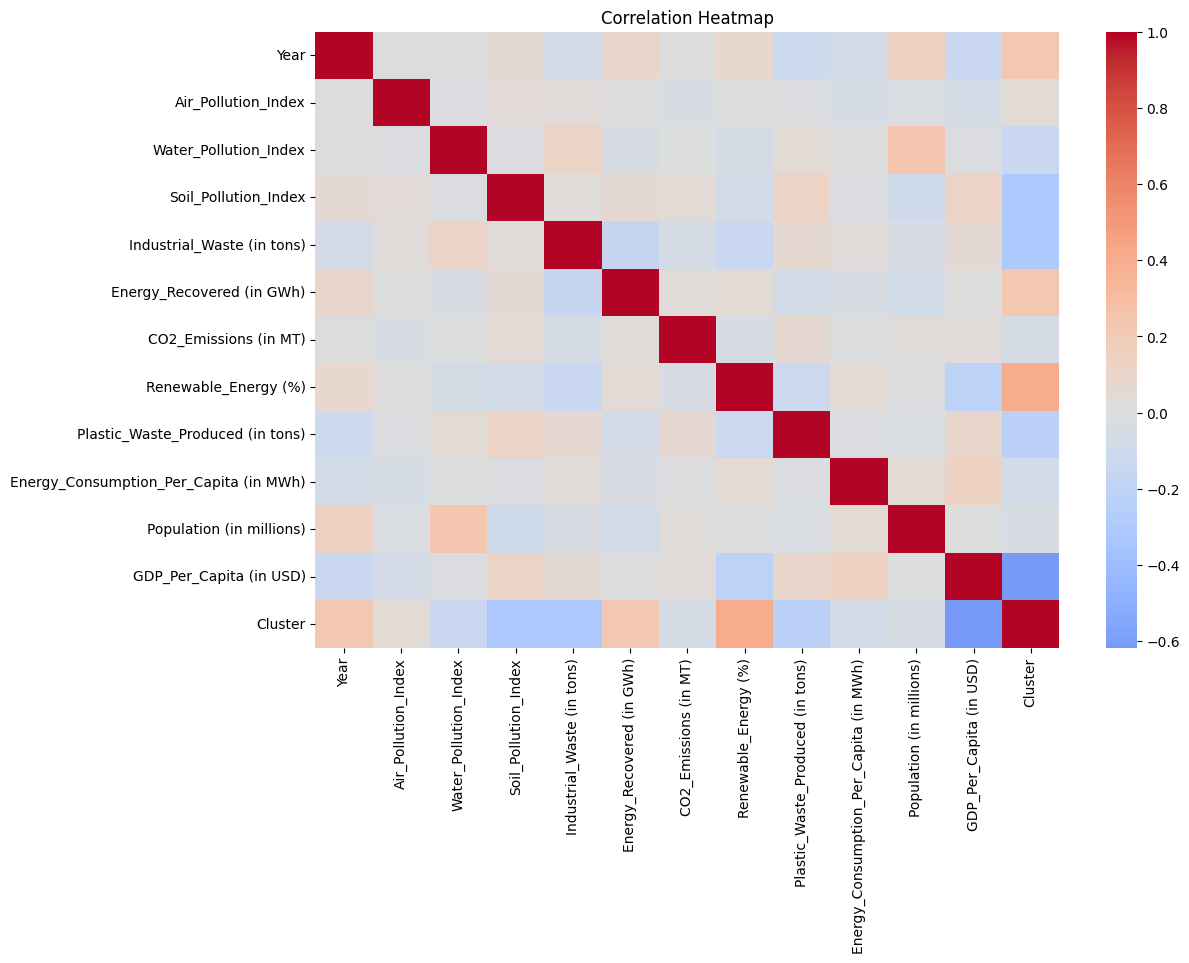

In [30]:
# ===============================
# STEP 16 — CORRELATION HEATMAP
# ===============================

plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap")
plt.show()

In [31]:
# ===============================
# STEP 17 — TOP FACTORS
# ===============================

corr_target = corr["Energy_Recovered (in GWh)"].sort_values(ascending=False)

print("Top factors influencing Energy Recovery:")
print(corr_target)

Top factors influencing Energy Recovery:
Energy_Recovered (in GWh)                 1.000000
Cluster                                   0.224763
Year                                      0.088332
Soil_Pollution_Index                      0.064076
Renewable_Energy (%)                      0.043533
CO2_Emissions (in MT)                     0.024758
GDP_Per_Capita (in USD)                   0.004535
Air_Pollution_Index                       0.002997
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Water_Pollution_Index                    -0.041828
Plastic_Waste_Produced (in tons)         -0.072946
Population (in millions)                 -0.075100
Industrial_Waste (in tons)               -0.161309
Name: Energy_Recovered (in GWh), dtype: float64


In [32]:
# ===============================
# STEP 18 — SAVE RESULTS
# ===============================

df.to_csv("clustered_energy_pollution_data.csv", index=False)

print("File saved successfully ✅")

File saved successfully ✅


In [33]:
# ===============================
# STEP 19 — FINAL CONCLUSION
# ===============================

print("\n📌 FINAL CONCLUSION")

best_r2 = max(
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_nn)
)

print(f"Best Model R² Score: {best_r2:.3f}")

print("""
• Waste generation strongly influences energy recovery.
• Regions differ significantly in efficiency (clusters).
• Renewable adoption improves outcomes.
• Pollution reduction correlates with better sustainability.
• Data-driven policies can optimize waste-to-energy systems.
""")


📌 FINAL CONCLUSION
Best Model R² Score: -0.370

• Waste generation strongly influences energy recovery.
• Regions differ significantly in efficiency (clusters).
• Renewable adoption improves outcomes.
• Pollution reduction correlates with better sustainability.
• Data-driven policies can optimize waste-to-energy systems.

